In [2]:
import tensorflow as tf

In [3]:
x1 = tf.constant(5)
x2 = tf.constant(6)
x3 = tf.add(x1,x2)

print(x3)

tf.Tensor(11, shape=(), dtype=int32)


In [4]:
v1 = tf.constant([1,2,3,4])
v2 = tf.constant([2,1,5,3])
v3 = tf.multiply(v1,v2)
v3.numpy()

array([ 2,  2, 15, 12], dtype=int32)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
data = pd.read_csv(r'C:\Users\Lenovo\Desktop\DEPI(R_2)\ML_git\GIZ4_AIS2_S1_Ml\src\DL\Session_1\Code\FuelConsumptionCo2.csv')

In [7]:
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [8]:
x_d = data.loc[:,'ENGINESIZE'].values
y_d = data.loc[:,'CO2EMISSIONS'].values

In [9]:
x = tf.constant(x_d, dtype=tf.float32)
y = tf.constant(y_d, dtype=tf.float32)

In [10]:
w = tf.Variable(2.0,dtype=tf.float32)
b = tf.Variable(7.2,dtype=tf.float32)

In [11]:
def Hypothesis_Term(x):
    y_p = w * x + b
    return y_p

In [12]:
def cost_func(y_acutal, y_pred):
    mse = tf.reduce_mean(tf.square(y_acutal - y_pred))
    return mse

In [13]:
lr = 0.01
epochs = 1000
loss_values = []
for epoch in range(epochs):
    with tf.GradientTape() as t:
        y_pred = Hypothesis_Term(x)
        loss = cost_func(y , y_pred)
        loss_values.append(loss)
        gradient = t.gradient(loss, [w , b])
        w.assign_sub(lr * gradient[0])
        b.assign_sub(lr * gradient[1])


In [14]:
loss

<tf.Tensor: shape=(), dtype=float32, numpy=951.5821533203125>

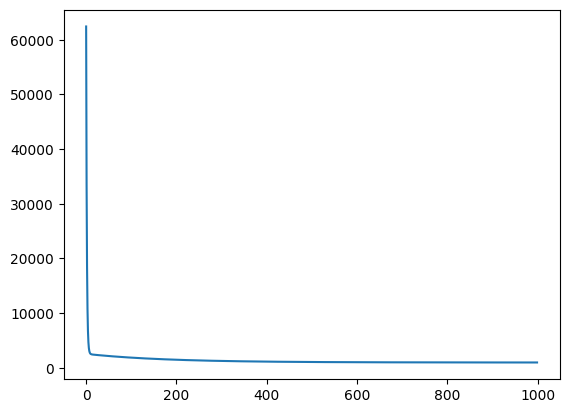

In [15]:
plt.plot(loss_values)
plt.show()

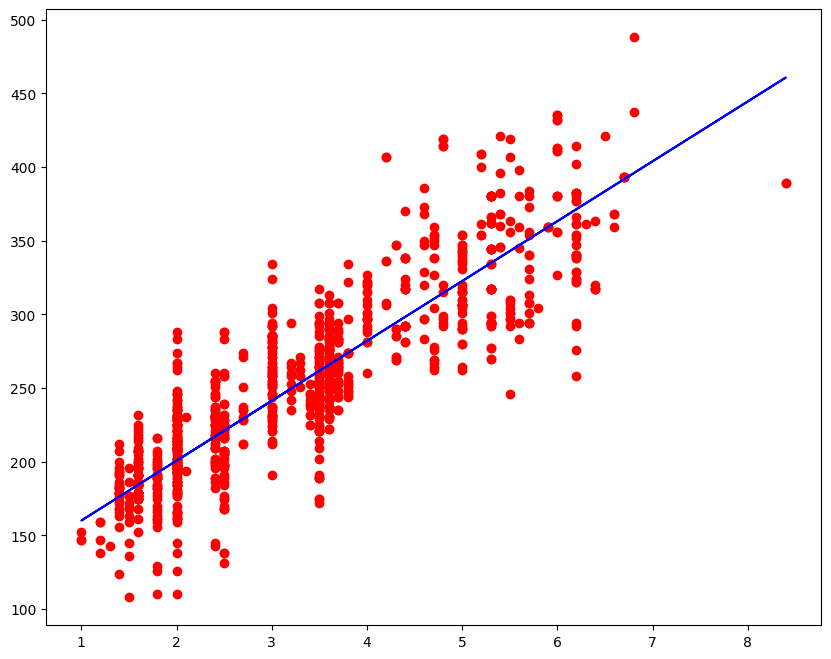

In [16]:
plt.figure(figsize=(10, 8))
plt.scatter(x.numpy(), y.numpy(), color='red')
plt.plot(x.numpy(), Hypothesis_Term(x).numpy(), color='blue')
plt.show()